In [8]:
'''
📌 1. Introduction

Tuberculosis (TB) is a serious infectious disease affecting millions worldwide. Early detection through chest X-ray analysis significantly improves patient outcomes.

This project:

Uses a real Kaggle TB Chest X-ray dataset

Performs detailed EDA (25+ visualizations)

Extracts image-based statistical features

Builds traditional ML models

Evaluates performance rigorously

important installations:
pip install opencv-python
'''

'\n📌 1. Introduction\n\nTuberculosis (TB) is a serious infectious disease affecting millions worldwide. Early detection through chest X-ray analysis significantly improves patient outcomes.\n\nThis project:\n\nUses a real Kaggle TB Chest X-ray dataset\n\nPerforms detailed EDA (25+ visualizations)\n\nExtracts image-based statistical features\n\nBuilds traditional ML models\n\nEvaluates performance rigorously\n\nimportant installations:\npip install opencv-python\n'

In [9]:
import os
import cv2
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

In [10]:
dataset_path = "/home/tendocaisey/Python/MachineLearning/TUBERCULOSIS-DETECTION-ML/TB_Chest_Radiography_Database"

classes = ["Normal", "Tuberculosis"]

image_paths = []
labels = []

for label in classes:
    folder = os.path.join(dataset_path, label)
    for file in os.listdir(folder):
        image_paths.append(os.path.join(folder, file))
        labels.append(label)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total Images:", len(df))
print(df['label'].value_counts())

Total Images: 4200
label
Normal          3500
Tuberculosis     700
Name: count, dtype: int64


In [11]:
missing_files = df[~df['image_path'].apply(os.path.exists)]
print("Missing files:", len(missing_files))

Missing files: 0


In [12]:
corrupt = []

for path in df['image_path']:
    try:
        img = Image.open(path)
        img.verify()
    except:
        corrupt.append(path)

print("Corrupt images:", len(corrupt))

Corrupt images: 0


In [13]:
def file_hash(filepath):
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

df['hash'] = df['image_path'].apply(file_hash)
print("Duplicate images:", df.duplicated('hash').sum())

Duplicate images: 3


In [14]:
def extract_features(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128,128))
    
    return [
        np.mean(img),
        np.std(img),
        np.min(img),
        np.max(img)
    ]

features = [extract_features(path) for path in df['image_path']]

feature_df = pd.DataFrame(features, columns=[
    "mean_pixel", "std_pixel", "min_pixel", "max_pixel"
])

df = pd.concat([df, feature_df], axis=1)
df['label'] = df['label'].map({"Normal":0, "Tuberculosis":1})


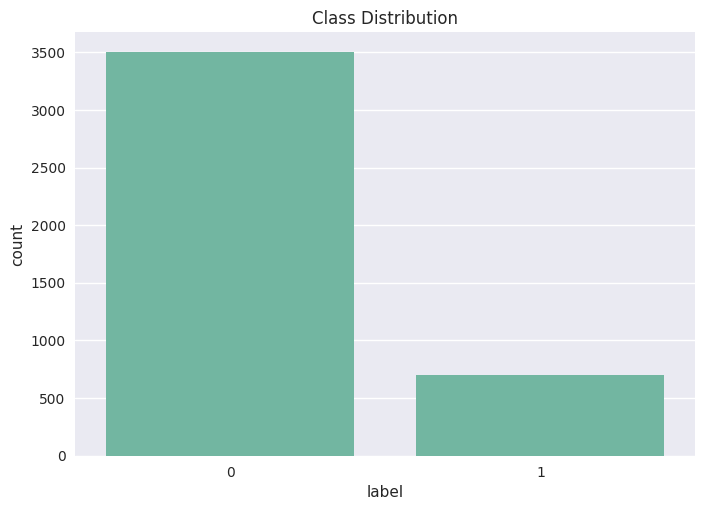

In [15]:
sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.show()

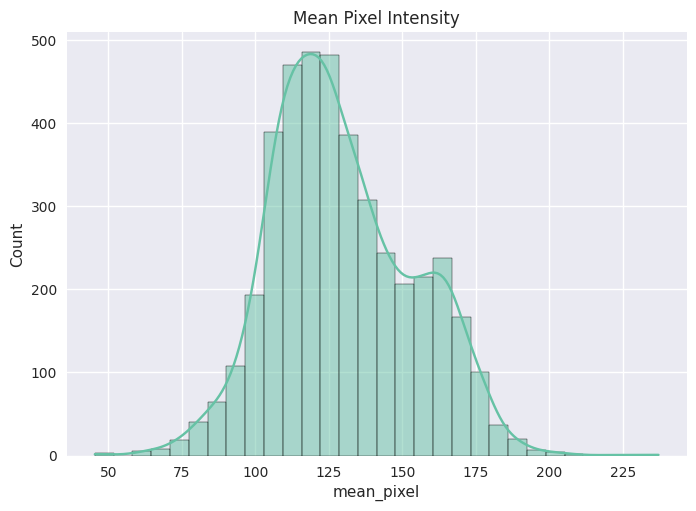

In [16]:
sns.histplot(df['mean_pixel'], bins=30, kde=True)
plt.title("Mean Pixel Intensity")
plt.show()

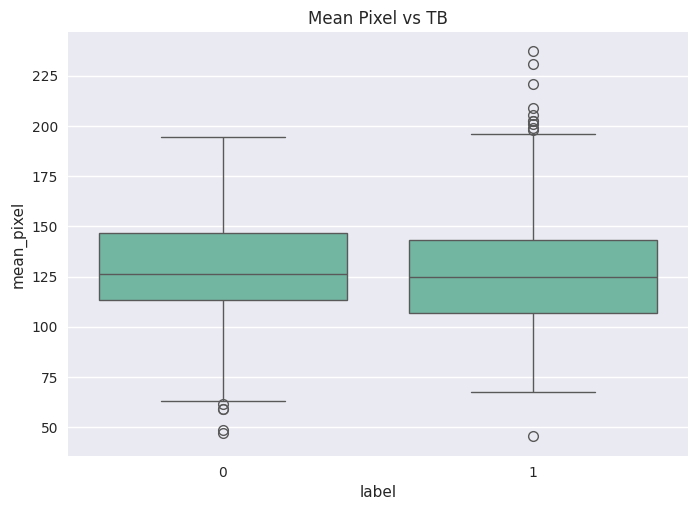

In [17]:
sns.boxplot(x='label', y='mean_pixel', data=df)
plt.title("Mean Pixel vs TB")
plt.show()

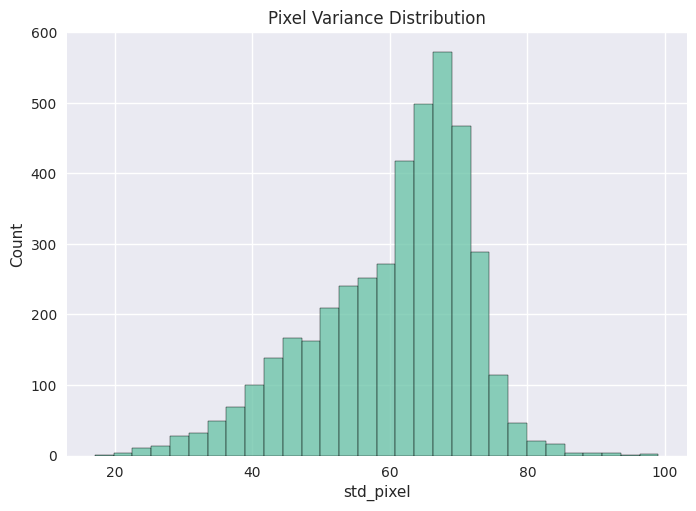

In [18]:
sns.histplot(df['std_pixel'], bins=30)
plt.title("Pixel Variance Distribution")
plt.show()

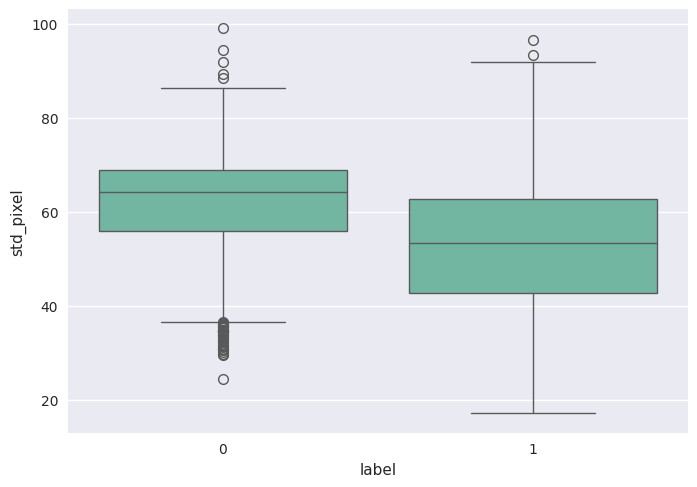

In [19]:
sns.boxplot(x='label', y='std_pixel', data=df)
plt.show()

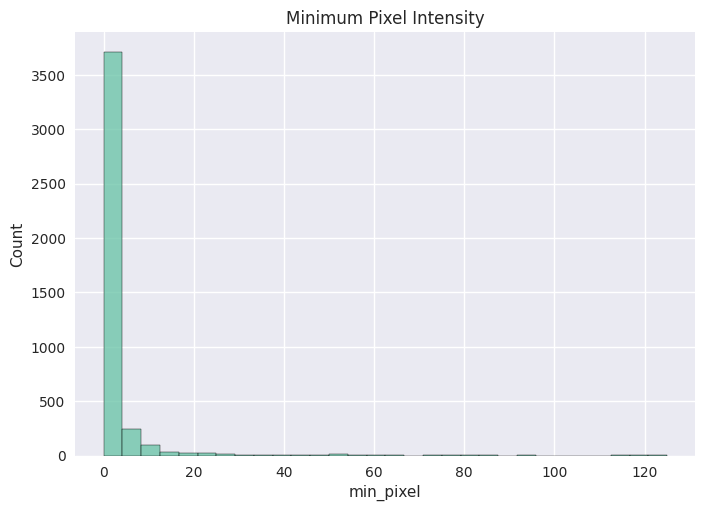

In [20]:
sns.histplot(df['min_pixel'], bins=30)
plt.title("Minimum Pixel Intensity")
plt.show()

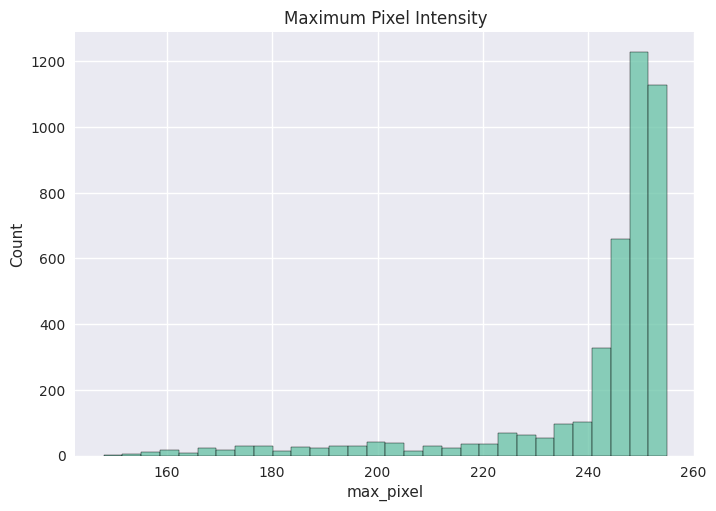

In [21]:
sns.histplot(df['max_pixel'], bins=30)
plt.title("Maximum Pixel Intensity")
plt.show()

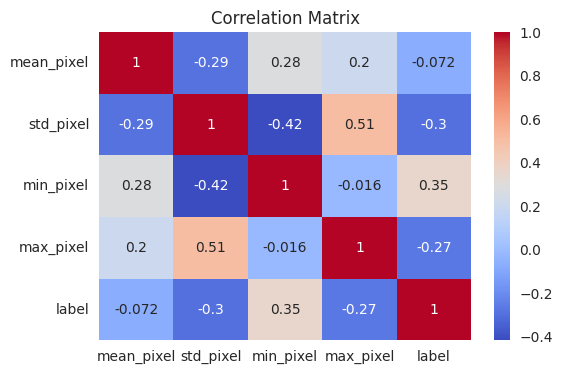

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['mean_pixel','std_pixel','min_pixel','max_pixel','label']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

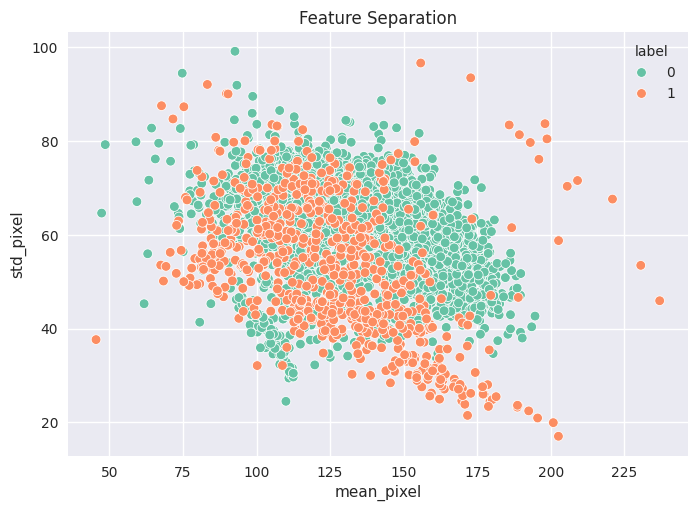

In [23]:
sns.scatterplot(x='mean_pixel', y='std_pixel', hue='label', data=df)
plt.title("Feature Separation")
plt.show()

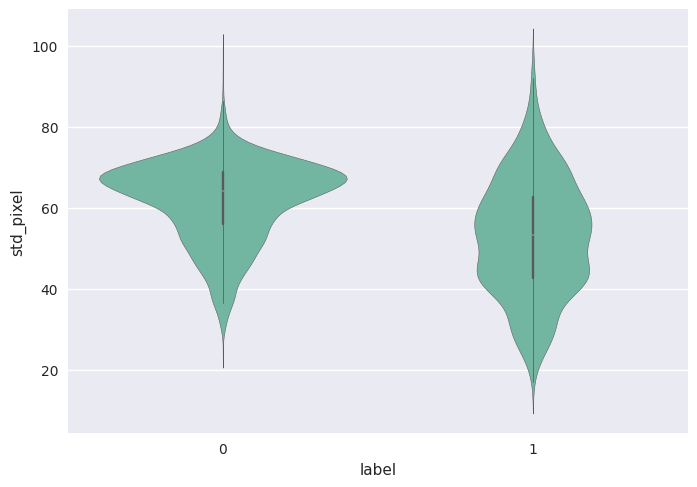

In [24]:
sns.violinplot(x='label', y='std_pixel', data=df)
plt.show()

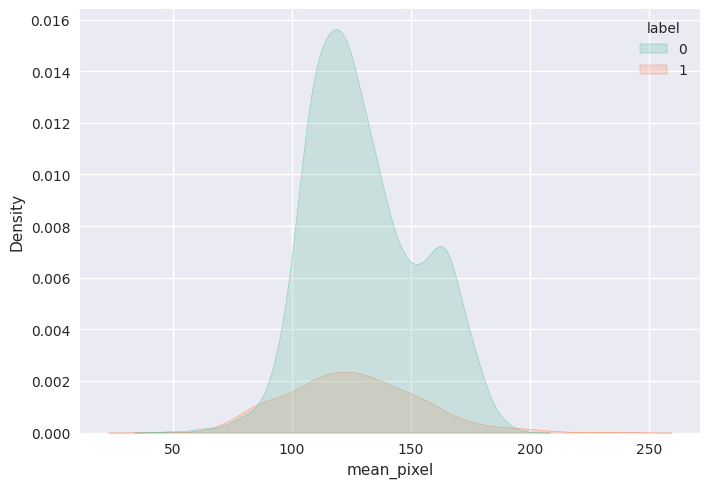

In [25]:
sns.kdeplot(data=df, x='mean_pixel', hue='label', fill=True)
plt.show()

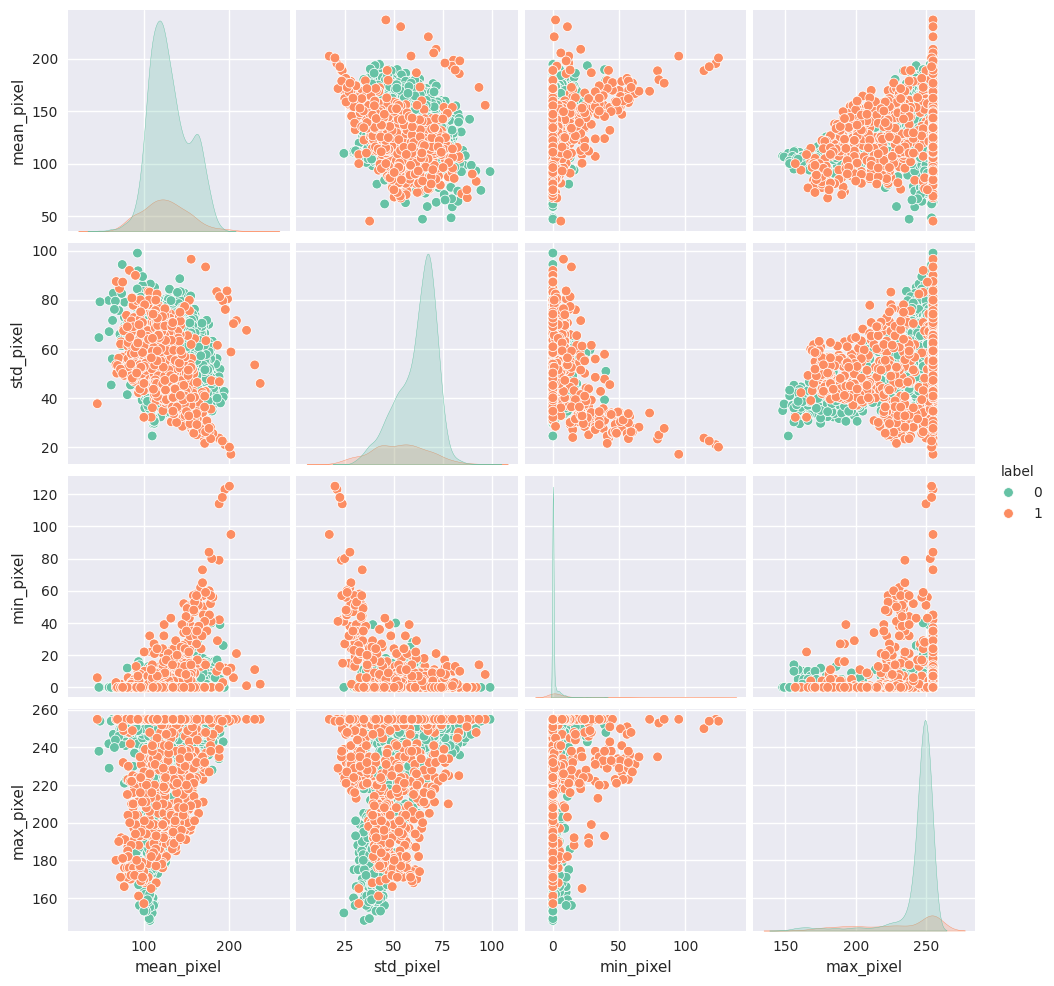

In [26]:
sns.pairplot(df[['mean_pixel','std_pixel','min_pixel','max_pixel','label']], hue='label')
plt.show()

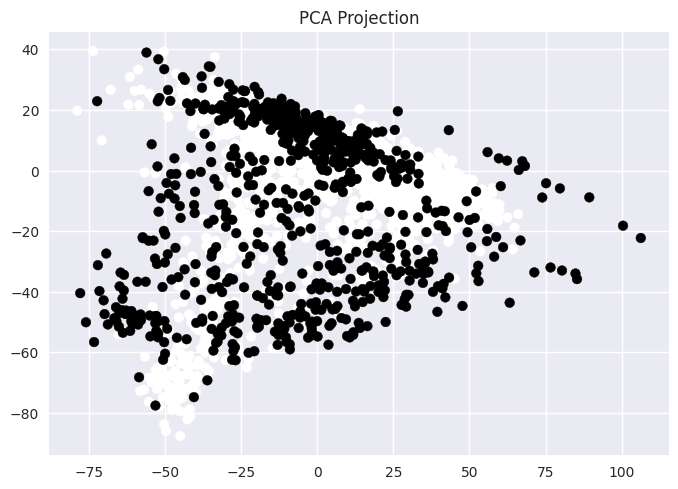

In [27]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df[['mean_pixel','std_pixel','min_pixel','max_pixel']])

plt.scatter(pca_features[:,0], pca_features[:,1], c=df['label'])
plt.title("PCA Projection")
plt.show()

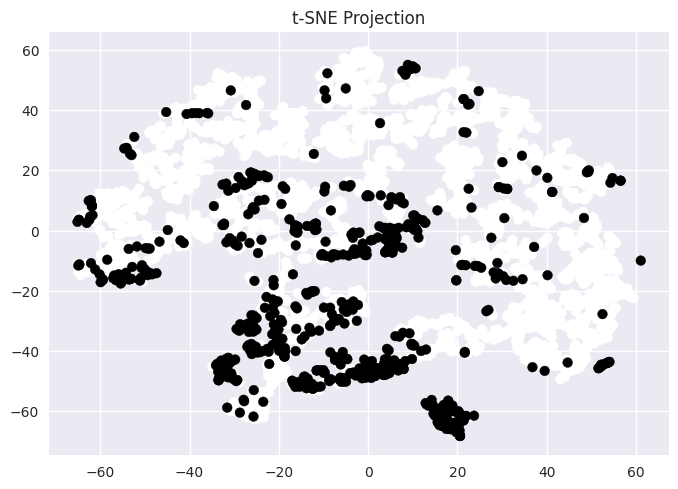

In [28]:
tsne = TSNE(n_components=2, random_state=42)
tsne_features = tsne.fit_transform(df[['mean_pixel','std_pixel','min_pixel','max_pixel']])

plt.scatter(tsne_features[:,0], tsne_features[:,1], c=df['label'])
plt.title("t-SNE Projection")
plt.show()

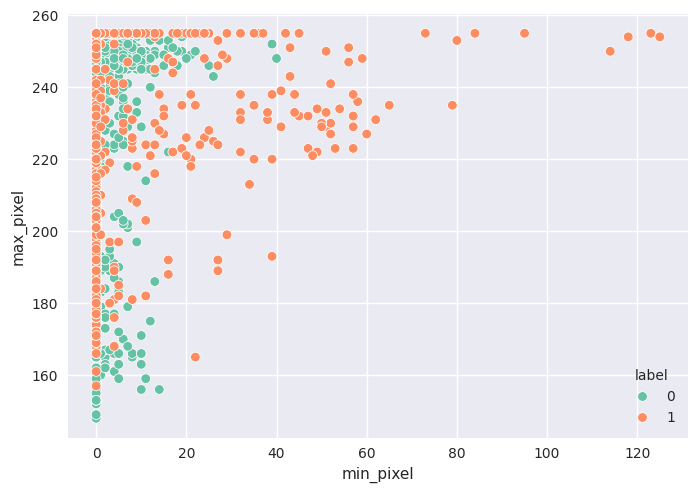

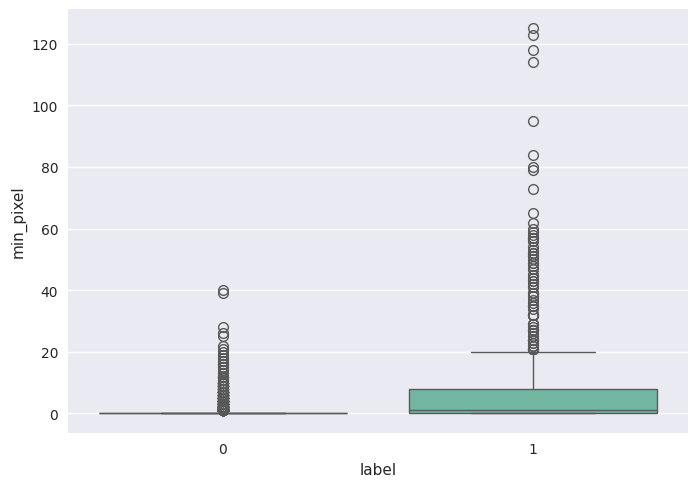

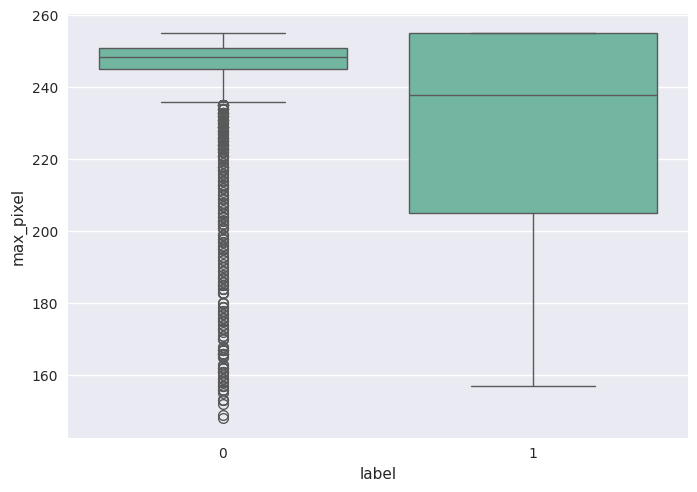

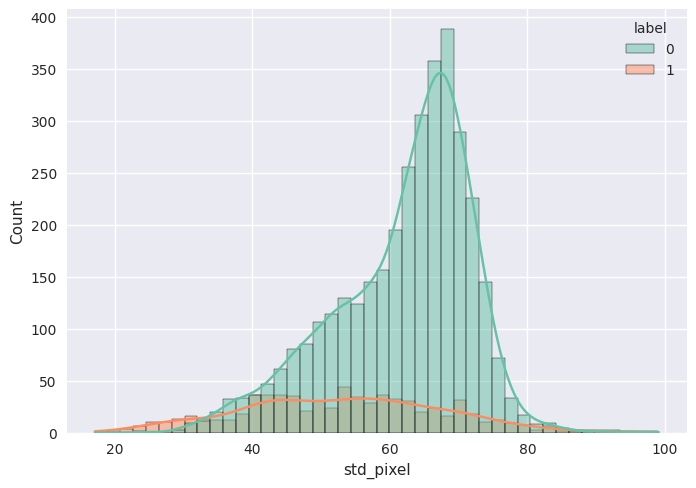

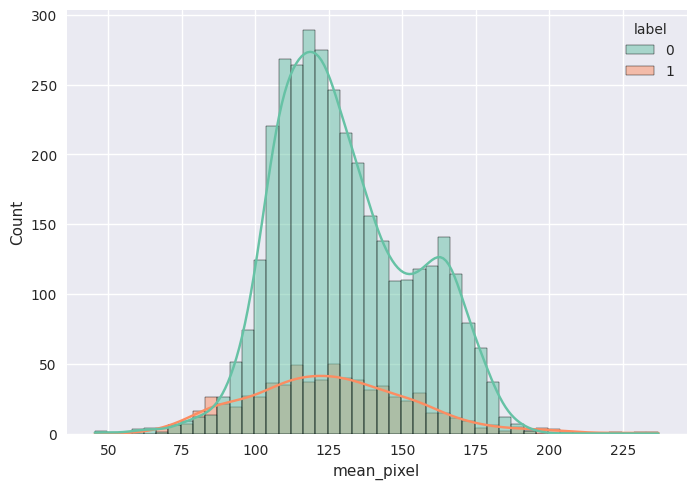

In [29]:
sns.scatterplot(x='min_pixel', y='max_pixel', hue='label', data=df)
plt.show()

sns.boxplot(x='label', y='min_pixel', data=df)
plt.show()

sns.boxplot(x='label', y='max_pixel', data=df)
plt.show()

sns.histplot(data=df, x='std_pixel', hue='label', kde=True)
plt.show()

sns.histplot(data=df, x='mean_pixel', hue='label', kde=True)
plt.show()

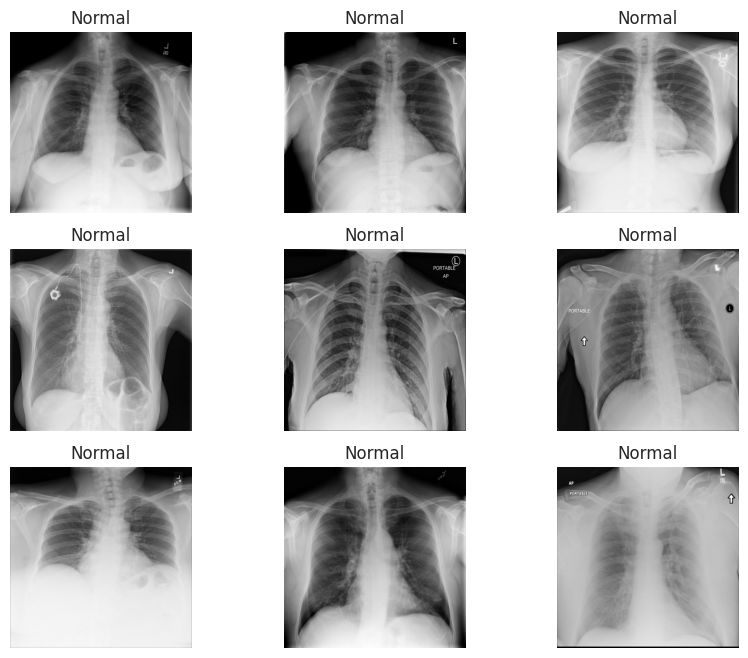

In [30]:
plt.figure(figsize=(10,8))
for i in range(9):
    img = cv2.imread(df.iloc[i]['image_path'], 0)
    plt.subplot(3,3,i+1)
    plt.imshow(img, cmap='gray')
    plt.title("TB" if df.iloc[i]['label']==1 else "Normal")
    plt.axis('off')
plt.show()